# 10_Hypothesis_Testing

### What is Hypothesis Testing?

Hypothesis testing is a statistical method used to decide, based on sample data, whether there is enough evidence to support a claim about a population. It compares an assumed default state (Null Hypothesis) against a claim of change or effect (Alternative Hypothesis) using probability.

Example

A pharma company wants to know if a new drug lowers blood pressure more than the existing one. Hypothesis testing helps decide, using sample trial data, whether the observed improvement is real or just due to random chance.

## 01. Null Hypothesis

**Definition**: The Null Hypothesis (H0) is the default assumption that there is no effect, no difference, or no relationship between variables. It is the statement a hypothesis test tries to find evidence against.

**Formula**: H0: μ = μ0 (population parameter equals a specified value, i.e., no effect)

**Where it is used**: Used as the starting assumption in every statistical hypothesis test, including t-tests, chi-square tests, and ANOVA.

**Real-World Example**: A pharma company assumes a new drug has no effect on blood pressure compared to a placebo (H0: μ_drug = μ_placebo).

**AI/ML Example**: In feature selection, the null hypothesis assumes a feature has no relationship with the target variable, and statistical tests are used to check if this assumption should be rejected.

In [9]:
import numpy as np
placebo = np.array([120,122,119,121,123,120,118,122])
drug = np.array([115,117,116,118,114,119,116,117])
print(np.mean(placebo))
print(np.mean(drug))

120.625
116.5


**Interpretation**: The null hypothesis assumes both groups have the same mean blood pressure; the sample means already show a difference, which the test will check for statistical significance.

## 02. Alternative Hypothesis

**Definition**: The Alternative Hypothesis (H1 or Ha) is the claim that contradicts the null hypothesis, stating that there is a real effect, difference, or relationship in the population.

**Formula**: H1: μ ≠ μ0 (two-tailed) or H1: μ > μ0 / μ < μ0 (one-tailed)

**Where it is used**: Used alongside the null hypothesis in every hypothesis test to represent what the researcher is trying to find evidence for.

**Real-World Example**: The alternative hypothesis that a new drug lowers blood pressure more than the existing treatment (H1: μ_drug < μ_placebo).

**AI/ML Example**: In A/B testing, the alternative hypothesis states that a new website design increases the conversion rate compared to the old design.

In [8]:
import numpy as np
from scipy import stats
placebo = np.array([120,122,119,121,123,120,118,122])
drug = np.array([115,117,116,118,114,119,116,117])
t_stat,p_value = stats.ttest_ind(placebo,drug)
print(t_stat)
print(p_value)

5.015816567776792
0.00018889586469767884


**Interpretation**: Since the p-value is very small, there is strong evidence to reject the null hypothesis in favor of the alternative hypothesis that the drug lowers blood pressure.

## 03. p-value

**Definition**: The p-value is the probability of observing a result as extreme as, or more extreme than, the sample result, assuming the null hypothesis is true. A small p-value indicates strong evidence against the null hypothesis.

**Formula**: p-value = P(Test Statistic as extreme as observed | H0 is true)

**Where it is used**: Used to make the accept/reject decision in t-tests, chi-square tests, ANOVA, and regression significance testing.

**Real-World Example**: A p-value of 0.02 in a clinical trial indicates only a 2% chance of seeing this improvement if the drug actually had no effect, suggesting the result is statistically significant.

**AI/ML Example**: p-values are used in statistical feature selection to test whether a feature's coefficient in a regression model is significantly different from zero.

In [7]:
import numpy as np
from scipy import stats
group_a = np.array([50,52,49,51,53,50,52,51])
group_b = np.array([55,57,54,56,58,55,57,56])
t_stat,p_value = stats.ttest_ind(group_a,group_b)
print(p_value)

2.3391120280605508e-06


**Interpretation**: The p-value is far below 0.05, so the difference between group A and group B is statistically significant and unlikely to be due to random chance.

## 04. Confidence Interval

**Definition**: A Confidence Interval (CI) is a range of values, calculated from sample data, that is likely to contain the true population parameter with a stated level of confidence, such as 95%.

**Formula**: CI = x̄ ± Z × (σ / √n)

where x̄ = sample mean, Z = Z-value for confidence level, σ = standard deviation, n = sample size

**Where it is used**: Used to estimate population parameters like mean or proportion, in election polling, A/B testing, and clinical research.

**Real-World Example**: A survey reports the average height of adults as 170 cm with a 95% confidence interval of [168 cm, 172 cm].

**AI/ML Example**: Confidence intervals are used to report the range of a model's accuracy across cross-validation folds, showing how reliable the performance estimate is.

In [10]:
import numpy as np
from scipy import stats
data = np.array([170,172,168,171,169,173,167,170,172,169])
mean = np.mean(data)
sem = stats.sem(data)
ci = stats.t.interval(0.95,len(data)-1,loc=mean,scale=sem)
print(mean)
print(ci)

170.1
(np.float64(168.732272848601), np.float64(171.46772715139898))


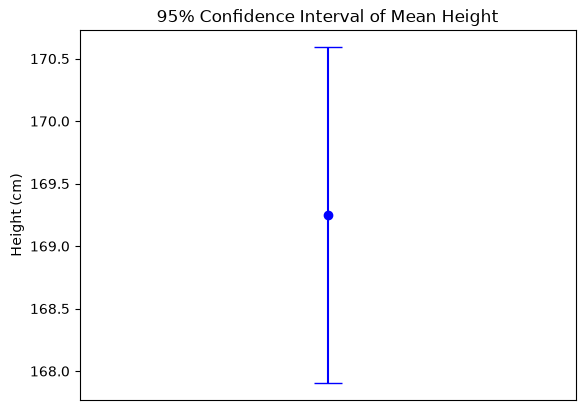

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
data = np.random.normal(170,4,30)
mean = np.mean(data)
sem = stats.sem(data)
ci = stats.t.interval(0.95,len(data)-1,loc=mean,scale=sem)
plt.errorbar(1,mean,yerr=(mean-ci[0]),fmt='o',capsize=10,color='blue')
plt.xlim(0,2)
plt.xticks([])
plt.ylabel('Height (cm)')
plt.title('95% Confidence Interval of Mean Height')
plt.show()

**Interpretation**: The plotted point shows the sample mean height, and the error bars represent the 95% confidence interval within which the true population mean is likely to lie.

## 05. Significance Level

**Definition**: The Significance Level (α) is the probability threshold chosen before conducting a test, used to decide whether to reject the null hypothesis. If the p-value is less than α, the null hypothesis is rejected.

**Formula**: Commonly used values: α = 0.05, α = 0.01, α = 0.10

**Where it is used**: Used to set the strictness of decision-making in hypothesis testing across scientific research, business experiments, and quality control.

**Real-World Example**: A medical study sets α = 0.05 before testing, meaning it accepts a 5% risk of wrongly concluding the drug works when it does not.

**AI/ML Example**: In A/B testing for a product feature rollout, a significance level of 0.05 is set beforehand to decide whether the observed lift in metrics is statistically significant before deploying the change.

In [5]:
alpha = 0.05
p_value = 0.03
if p_value < alpha:
    print('Reject Null Hypothesis')
else:
    print('Fail to Reject Null Hypothesis')

Reject Null Hypothesis


**Interpretation**: Since the p-value (0.03) is less than the significance level (0.05), the null hypothesis is rejected, indicating a statistically significant result.

## 06. Type I Error

**Definition**: A Type I Error occurs when the null hypothesis is rejected even though it is actually true, also known as a false positive. Its probability is equal to the significance level (α).

**Formula**: P(Type I Error) = α

**Where it is used**: Considered during hypothesis test design in medical testing, quality control, and legal decision-making, where false positives carry consequences.

**Real-World Example**: Convicting an innocent person in court is a Type I Error, since the null hypothesis of innocence was true but was wrongly rejected.

**AI/ML Example**: A fraud detection model flagging a genuine transaction as fraudulent is a Type I Error, causing unnecessary friction for a legitimate customer.

In [4]:
import numpy as np
from scipy import stats
np.random.seed(1)
alpha = 0.05
false_positives = 0
trials = 1000
for i in range(trials):
    sample = np.random.normal(0,1,30)
    t_stat,p_value = stats.ttest_1samp(sample,0)
    if p_value < alpha:
        false_positives += 1
print(false_positives/trials)

0.055


**Interpretation**: Even though the true population mean is 0 (null hypothesis is true), about 5% of the trials incorrectly reject it, matching the chosen significance level of 0.05.

## 07. Type II Error

**Definition**: A Type II Error occurs when the null hypothesis is not rejected even though it is actually false, also known as a false negative. Its probability is denoted by β, and 1−β is called the statistical power of the test.

**Formula**: P(Type II Error) = β

**Where it is used**: Considered during sample size and power analysis in medical diagnostics, quality control, and scientific research design.

**Real-World Example**: A diagnostic test failing to detect a disease in a patient who actually has it is a Type II Error, since the true positive case was missed.

**AI/ML Example**: A fraud detection model failing to flag an actual fraudulent transaction as fraud is a Type II Error, letting real fraud pass through undetected.

In [3]:
import numpy as np
from scipy import stats
np.random.seed(1)
alpha = 0.05
missed_detections = 0
trials = 1000
for i in range(trials):
    sample = np.random.normal(0.3,1,30)
    t_stat,p_value = stats.ttest_1samp(sample,0)
    if p_value >= alpha:
        missed_detections += 1
print(missed_detections/trials)

0.656


**Interpretation**: Even though the true population mean is actually 0.3 (null hypothesis is false), a notable fraction of trials fail to detect this small effect, showing the risk of a Type II Error.

## 08. One-tailed Test

**Definition**: A One-tailed Test checks for an effect in only one specific direction, either greater than or less than the null hypothesis value, placing the entire rejection region on one side of the distribution.

**Formula**: H1: μ > μ0 or H1: μ < μ0; reject H0 if the test statistic falls beyond the critical value on that single side.

**Where it is used**: Used when the researcher is only interested in a directional effect, such as an increase or a decrease, not both.

**Real-World Example**: Testing whether a new fertilizer increases crop yield compared to the current fertilizer, where only an increase is of interest.

**AI/ML Example**: Testing whether a new machine learning model has significantly higher accuracy than the existing baseline model, where only improvement matters.

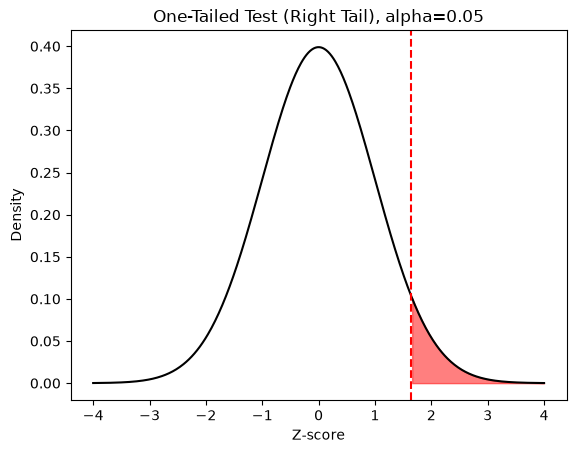

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
x = np.linspace(-4,4,500)
y = stats.norm.pdf(x,0,1)
critical = stats.norm.ppf(0.95)
plt.plot(x,y,color='black')
plt.fill_between(x,y,where=(x>=critical),color='red',alpha=0.5)
plt.axvline(critical,color='red',linestyle='--')
plt.title('One-Tailed Test (Right Tail), alpha=0.05')
plt.xlabel('Z-score')
plt.ylabel('Density')
plt.show()

**Interpretation**: The shaded red region on the right represents the rejection zone; if the test statistic falls in this single tail, the null hypothesis is rejected in favor of the one-directional alternative.

## 09. Two-tailed Test

**Definition**: A Two-tailed Test checks for an effect in either direction, testing whether a parameter is simply different from the null value, without assuming whether it is greater or smaller. The rejection region is split across both sides of the distribution.

**Formula**: H1: μ ≠ μ0; reject H0 if the test statistic falls beyond the critical value on either the left or the right side.

**Where it is used**: Used when the direction of the effect is unknown beforehand and any significant difference, in either direction, is of interest.

**Real-World Example**: Testing whether a coin is fair, where the outcome could be biased toward either heads or tails.

**AI/ML Example**: Testing whether two machine learning models have significantly different accuracy, without assuming in advance which model would perform better.

In [1]:
import numpy as np
from scipy import stats
model_a = np.array([0.91,0.89,0.92,0.90,0.91,0.93,0.89])
model_b = np.array([0.85,0.87,0.86,0.88,0.84,0.86,0.87])
t_stat,p_value = stats.ttest_ind(model_a,model_b)
print(t_stat)
print(p_value)

6.011753194417429
6.105686122205609e-05


**Interpretation**: The very small two-tailed p-value shows a statistically significant difference between the two models' accuracies, without assuming beforehand which model would be better.

## Overall Advantages and Limitations of Hypothesis Testing

### Advantages
1. Provides an objective, statistical framework for making decisions based on sample data rather than intuition.
2. Quantifies uncertainty through p-values and confidence intervals, allowing informed risk-based decisions.
3. Widely applicable across domains such as medicine, business, engineering, and machine learning model evaluation.
4. Enables comparison between groups, treatments, or models to check if observed differences are real or due to chance.
5. Structured process (null vs alternative, significance level, error types) ensures consistent and repeatable decision-making.

### Limitations
1. A statistically significant result does not always imply practical or real-world significance.
2. Misinterpretation of p-values (e.g., treating them as the probability H0 is true) is common and misleading.
3. Choice of significance level (α) is somewhat arbitrary and affects the balance between Type I and Type II errors.
4. Results can be sensitive to sample size; very large samples can make even trivial differences appear significant.
5. Assumes the sample is representative and, for many tests, that data follows a specific distribution (e.g., normality).

## Interview Questions & Answers

**1. What is the difference between the null hypothesis and the alternative hypothesis?**
The null hypothesis (H0) assumes there is no effect or difference and represents the status quo, while the alternative hypothesis (H1) is the claim of an actual effect or difference that the test tries to find evidence for.

**2. What does a p-value actually represent, and what is a common misconception about it?**
A p-value is the probability of observing a result as extreme as the sample result assuming the null hypothesis is true; a common misconception is treating it as the probability that the null hypothesis itself is true, which is incorrect.

**3. What is the difference between Type I and Type II errors?**
A Type I error is rejecting a true null hypothesis (false positive) with probability α, while a Type II error is failing to reject a false null hypothesis (false negative) with probability β.

**4. When would you use a one-tailed test instead of a two-tailed test?**
A one-tailed test is used when you are only interested in detecting an effect in one specific direction (e.g., only an increase), while a two-tailed test is used when a difference in either direction is meaningful.

**5. How is a confidence interval related to hypothesis testing?**
A confidence interval gives a range of plausible values for a population parameter, and if the null hypothesis value falls outside a 95% confidence interval, it would typically be rejected at the corresponding 0.05 significance level.

**6. What is the significance level, and how does it relate to Type I error?**
The significance level (α) is the threshold probability chosen before testing to decide when to reject the null hypothesis, and it is exactly equal to the probability of making a Type I error.

**7. What is statistical power, and how does it relate to Type II error?**
Statistical power (1−β) is the probability of correctly rejecting a false null hypothesis, so it is the complement of the Type II error rate; higher power means a lower chance of missing a real effect.

## Self-Reflection

Working through this notebook helped me understand that hypothesis testing is fundamentally about managing uncertainty and risk when making decisions from sample data rather than the full population. The key insight I take away is that null and alternative hypotheses, p-values, and significance levels are all interconnected parts of the same decision framework, and the choice between a one-tailed and two-tailed test depends entirely on whether the research question is directional. I also now understand that Type I and Type II errors represent a trade-off — lowering one often raises the other — and that no test result is meaningful without considering both statistical and practical significance. This connects directly to real ML workflows, where A/B testing and model comparison rely on the exact same logic to decide whether an observed improvement is genuine or just noise.